In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
url = "https://docs.google.com/spreadsheets/d/1J1Eq8QI2Mz27E9iY5QB9IGmqDqaqwNAQ/export?format=xlsx"

# Đọc tất cả sheet
xls = pd.ExcelFile(url)
sheet_names = xls.sheet_names

print("Danh sách sheet:")
print(sheet_names)

# Load từng sheet vào dictionary
data = {sheet: pd.read_excel(xls, sheet) for sheet in sheet_names}

# Xem 5 dòng đầu mỗi sheet
for name, df in data.items():
    print(f"\n===== Sheet: {name} =====")
    print(df.head())


Danh sách sheet:
['Info', 'Defect Type', 'Defect', 'Material Type', 'Metrics', 'Plant', 'Category', 'Vendor', 'Date']

===== Sheet: Info =====
                               Unnamed: 0  \
0                             Tên dataset   
1                         Ngày cập nhật:    
2                               Context:    
3                                     NaN   
4  Giải thích dữ liệu: Bảng Fact: Metrics   

                                          Unnamed: 1 Unnamed: 2  
0               Quality Analysis sample for Power BI        NaN  
1                                         26/08/2021        NaN  
2  Công ty VietFast là công ty sản xuất đồ chơi h...        NaN  
3                                                NaN        NaN  
4                                                NaN        NaN  

===== Sheet: Defect Type =====
  Defect Type  Defect Type ID  Sort
0   No Impact               1     3
1      Impact               3     2
2    Rejected               4     1

===== Sheet: 

In [44]:
# Clean data
df = df.drop_duplicates()

# Tránh chia cho 0
df['Defect Qty'] = df['Defect Qty'].fillna(0)
df['Downtime (min)'] = df['Downtime (min)'].fillna(0)

In [3]:
#Tìm xem bảng Metrics có thể liên kết với các bảng khác qua cột nào, tìm quan hệ PK-FK
metrics = data["Metrics"]

relationships = []

for dim_name, dim_df in data.items():
    if dim_name == "Metrics":
        continue

    for col in metrics.columns:
        if col in dim_df.columns:
            relationships.append((f"Metrics.{col}", f"{dim_name}.{col}"))

print("\n=== Quan hệ PK–FK tìm được ===")
for rel in relationships:
    print(rel)



=== Quan hệ PK–FK tìm được ===
('Metrics.Defect Type ID', 'Defect Type.Defect Type ID')
('Metrics.Defect ID', 'Defect.Defect ID')
('Metrics.Material Type ID', 'Material Type.Material Type ID')
('Metrics.Plant ID', 'Plant.Plant ID')
('Metrics.Sub Category ID', 'Category.Sub Category ID')
('Metrics.Vendor ID', 'Vendor.Vendor ID')
('Metrics.Date', 'Date.Date')


In [4]:
print("\n=== STAR SCHEMA ===")
print("FACT: Metrics")
for fact, dim in relationships:
    print(f"   {fact}  --->  {dim}")



=== STAR SCHEMA ===
FACT: Metrics
   Metrics.Defect Type ID  --->  Defect Type.Defect Type ID
   Metrics.Defect ID  --->  Defect.Defect ID
   Metrics.Material Type ID  --->  Material Type.Material Type ID
   Metrics.Plant ID  --->  Plant.Plant ID
   Metrics.Sub Category ID  --->  Category.Sub Category ID
   Metrics.Vendor ID  --->  Vendor.Vendor ID
   Metrics.Date  --->  Date.Date


In [5]:
# LẤY BẢNG FACT METRICS VÀ CHUẨN HÓA DATE
# ============================================================

df = data["Metrics"]

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Month"] = df["Date"].dt.to_period("M")

print("\n== Fact Metrics After Cleaning ==")
print(df.head())


# ============================================================
# 4. JOIN FACT + DIMENSIONS (giống quan hệ Power BI)
# ============================================================

df = df.merge(data["Vendor"], on="Vendor ID", how="left") \
       .merge(data["Plant"], on="Plant ID", how="left") \
       .merge(data["Material Type"], on="Material Type ID", how="left") \
       .merge(data["Category"], on="Sub Category ID", how="left") \
       .merge(data["Defect"], on="Defect ID", how="left") \
       .merge(data["Defect Type"], on="Defect Type ID", how="left") \
       .merge(data["Date"], on="Date", how="left")

print("\n== DATA AFTER JOINING FACT + DIM ==")
print(df.head())


== Fact Metrics After Cleaning ==
        Date  Sub Category ID  Plant ID  Vendor ID  Material ID  \
0 2014-12-31                2        16          2         2126   
1 2014-12-31                2        16          2         2126   
2 2014-12-31                2        16          2         2137   
3 2014-12-31                2        20         59         1439   
4 2014-12-31                2         2         46          607   

   Defect Type ID  Material Type ID  Defect ID  Defect Qty  Downtime (min)  \
0               3                 4         27           0              60   
1               3                 4         27           0              60   
2               3                 6        281           1              60   
3               3                 8        295           9              10   
4               3                 8        299          47              30   

     Month  
0  2014-12  
1  2014-12  
2  2014-12  
3  2014-12  
4  2014-12  

== DATA AFTER 

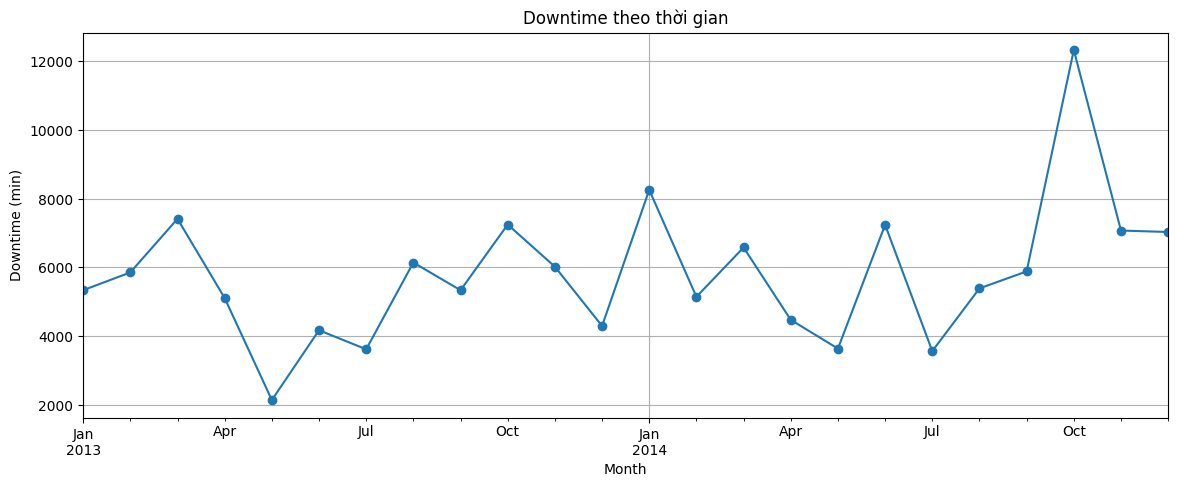

In [6]:
#ANALYSIS 1 — DOWNTIME THEO THỜI GIAN (LINE CHART)
# ============================================================

downtime_trend = df.groupby("Month")["Downtime (min)"].sum()

plt.figure(figsize=(14,5))
downtime_trend.plot(marker="o")
plt.title("Downtime theo thời gian")
plt.xlabel("Month")
plt.ylabel("Downtime (min)")
plt.grid(True)
plt.show()

/tmp/ipykernel_9072/3302497283.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plant_dt.values, y=plant_dt.index, palette="Reds_r")


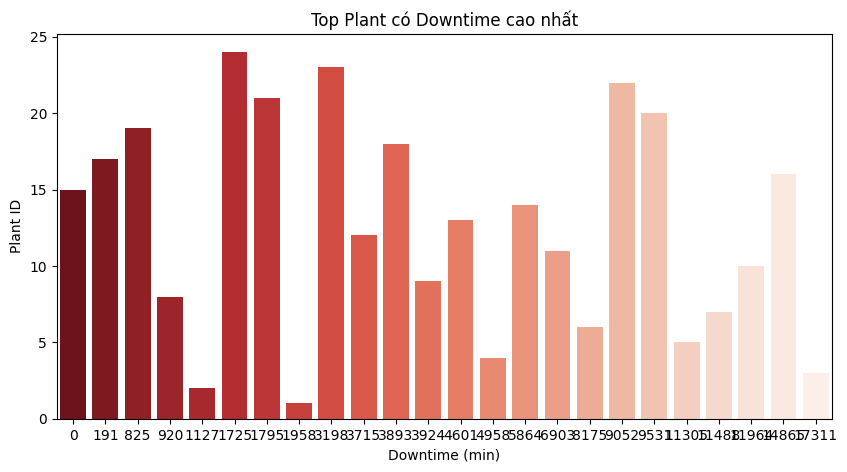

In [7]:
# ANALYSIS 2 — TOP PLANT CÓ DOWNTIME CAO NHẤT
# ============================================================

plant_dt = df.groupby("Plant ID")["Downtime (min)"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=plant_dt.values, y=plant_dt.index, palette="Reds_r")
plt.title("Top Plant có Downtime cao nhất")
plt.xlabel("Downtime (min)")
plt.ylabel("Plant ID")
plt.show()

/tmp/ipykernel_9072/2473403111.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendor_defects.values, y=vendor_defects.index, palette="Blues_r")


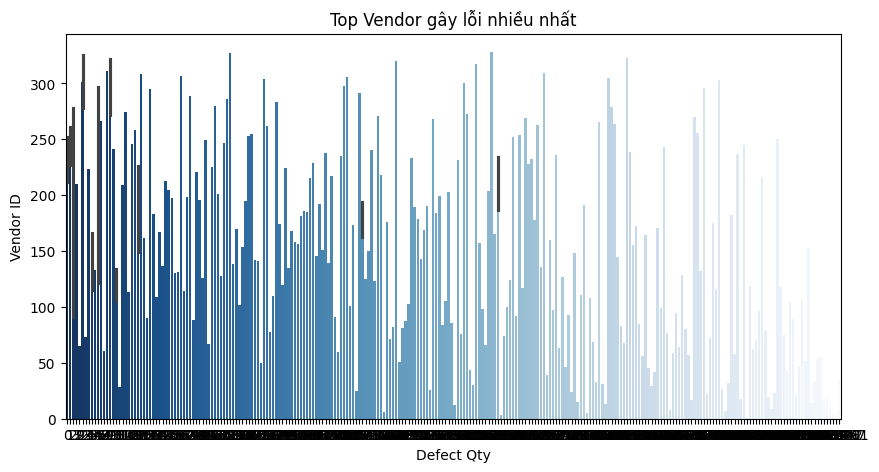

In [8]:
# ANALYSIS 3 — TOP VENDOR GÂY LỖI NHIỀU NHẤT
# ============================================================

vendor_defects = df.groupby("Vendor ID")["Defect Qty"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=vendor_defects.values, y=vendor_defects.index, palette="Blues_r")
plt.title("Top Vendor gây lỗi nhiều nhất")
plt.xlabel("Defect Qty")
plt.ylabel("Vendor ID")
plt.show()

In [34]:
# Tổng lỗi theo từng Vendor
total_defect = df.groupby('Vendor')['Defect Qty'].sum().sort_values(ascending=False)
print (total_defect)

Vendor
Solholdings     3977962
Plustax         3836303
Quotelane       3095198
Dentocity       2982348
Recode          2589319
                 ...   
Daltron               0
Danfan                0
dripkix               0
wareholding           0
zen-holdings          0
Name: Defect Qty, Length: 318, dtype: int64


In [35]:
# Đánh giá lỗi (nhiều hay ít) mỗi lần phát sinh
avg_defect = df.groupby('Vendor')['Defect Qty'].mean().sort_values(ascending=False)
print (avg_defect)

Vendor
hotity          204781.0
Plextechi       161535.0
O-ace           131008.0
Scotlex         128160.0
Whitefan        109559.0
                  ...   
Daltron              0.0
Daltcare             0.0
betaity              0.0
wareholding          0.0
zen-holdings         0.0
Name: Defect Qty, Length: 318, dtype: float64


In [36]:
# Vendor nào có time dừng nhiều nhất
downtime = df.groupby('Vendor')['Downtime (min)'].sum().sort_values(ascending=False)
print (downtime)

Vendor
Reddoit           26185
Plustax           10330
Sanlab            10275
xx-way             9966
Quotelane          5831
                  ...  
Cityis                0
Carekix               0
Canphase              0
Canex                 0
Canetechnology        0
Name: Downtime (min), Length: 318, dtype: int64


In [37]:
# Tần suất lỗi của Vendor
freq = df.groupby('Vendor')['Defect ID'].count().sort_values(ascending=False)
print (freq)

Vendor
Reddoit       706
xx-way        402
Quotelane     380
Plustax       308
Subdrill      251
             ... 
openzap         1
saltlab         1
san-plex        1
Bamgeohigh      1
Anmedia         1
Name: Defect ID, Length: 318, dtype: int64


In [38]:
# lỗi của Vendor nào nghiêm trọng hơn
df = df.drop_duplicates()
df['downtime_per_defect'] = df['Downtime (min)'] / df['Defect Qty'].replace(0,1).sort_values(ascending=False)
print (df['downtime_per_defect'])

0       60.000000
2       60.000000
3        1.111111
4        0.638298
5        0.010895
          ...    
6140     0.000000
6141     0.000000
6142     0.000000
6143     0.000000
6144     0.000000
Name: downtime_per_defect, Length: 5952, dtype: float64


In [39]:
#Vendor  hay bị lỗi nhất
df[df['Defect Qty'] > 0].groupby('Vendor').size().sort_values(ascending=False)

,0
Vendor,
Reddoit,637
xx-way,392
Quotelane,275
Plustax,229
Subdrill,227
...,...
hexzim,1
Anzammedia,1
hotity,1


In [24]:
# Top 5 vendor tệ nhất
df.groupby('Vendor')['Defect Qty'].sum().sort_values(ascending=False).head(5)

,Defect Qty
Vendor,
Solholdings,3977962
Plustax,3836303
Quotelane,3095198
Dentocity,2982348
Recode,2589319


In [40]:
#Mỗi lỗi gây downtime nặng hay nhẹ
df.groupby('Vendor')['Downtime (min)'].mean().sort_values(ascending=False)

,Downtime (min)
Vendor,
O-ace,720.0
Donware,375.0
white-high,360.0
citydexon,333.0
Latgotrax,240.0
...,...
Cityis,0.0
Carekix,0.0
Canphase,0.0


In [41]:
#Vendor nào yếu ở loại vật liệu nào
df.groupby(['Vendor', 'Material Type'])['Defect Qty'].sum().sort_values(ascending=False)

,,Defect Qty
Vendor,Material Type,
Dentocity,Film,2403439
Solholdings,Film,2322706
Plustax,Controllers,2286200
Recode,Carton,2266878
Quotelane,Labels,2200319
...,...,...
saltlab,Raw Materials,0
san-plex,Raw Materials,0
stripzim,Raw Materials,0


In [42]:
#Vendor có vấn đề ở nhà máy nào
df.groupby(['Vendor', 'Plant'])['Defect Qty'].sum().sort_values(ascending=False)

,,Defect Qty
Vendor,Plant,
Plustax,"Springfield, IL",3176376
Instrip,"Rockford, IL",1828614
Bamtechnology,"Detriot, MI",1806844
Planethouse,"Northbrook, IL",1681683
Dentocity,"Monon, IN",1641415
...,...,...
Canphase,"Monon, IN",0
Carekix,"Chicago, IL",0
Condexon,"Monon, IN",0


In [43]:
# Loại lỗi ->root cause analysis
df.groupby(['Vendor', 'Defect Type'])['Defect Qty'].sum().sort_values(ascending=False)



,,Defect Qty
Vendor,Defect Type,
Plustax,Impact,3267202
Solholdings,Rejected,2020209
Planethouse,Rejected,1540204
Solholdings,Impact,1423984
Recode,Impact,1244949
...,...,...
techmedia,No Impact,0
una-phase,No Impact,0
tinron,No Impact,0


Top 5 vendor có lỗi nhiều nhất:

Solholdings	3977962
Plustax	3836303
Quotelane	3095198
Dentocity	2982348
Recode	2589319



In [45]:
# Cách 2: làm gộp
#vendor nào có tổng lỗi, time chờ, tần suất  nhiều nhất
kpi_vendor = df.groupby('Vendor').agg({
    'Defect Qty': 'sum',
    'Downtime (min)': 'sum',
    'Defect ID': 'count'
}).reset_index()

kpi_vendor.columns = ['Vendor', 'Total Defect', 'Total Downtime', 'Defect Frequency']

# Xác định vendor nào gây lỗi nhiều, time dừng trên từng lỗi
kpi_vendor['Avg Defect'] = kpi_vendor['Total Defect'] / kpi_vendor['Defect Frequency']
kpi_vendor['Downtime per Defect'] = kpi_vendor['Total Downtime'] / kpi_vendor['Total Defect'].replace(0,1)

# Sort DESC
kpi_vendor = kpi_vendor.sort_values(by='Total Defect', ascending=False)

print(kpi_vendor.head(10))

            Vendor  Total Defect  Total Downtime  Defect Frequency  \
188    Solholdings       3977962            2275               116   
153        Plustax       3836303           10330               308   
157      Quotelane       3095198            5831               380   
34       Dentocity       2982348            3088               187   
162         Recode       2589319            4215                96   
291        ontotam       2005374            3327               152   
98         Instrip       1828614            3088                69   
5    Bamtechnology       1810404            1030                57   
146    Planethouse       1681683            3382                70   
204       Subdrill       1273832            2221               251   

       Avg Defect  Downtime per Defect  
188  34292.775862             0.000572  
153  12455.529221             0.002693  
157   8145.257895             0.001884  
34   15948.385027             0.001035  
162  26972.072917       

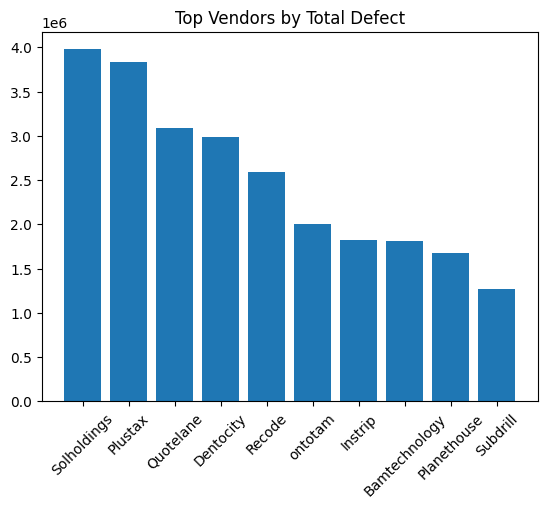

In [46]:
#Top Vendor lỗi nhiều nhất
top_vendor = kpi_vendor.head(10)

plt.figure()
plt.bar(top_vendor['Vendor'], top_vendor['Total Defect'])
plt.xticks(rotation=45)
plt.title('Top Vendors by Total Defect')
plt.show()

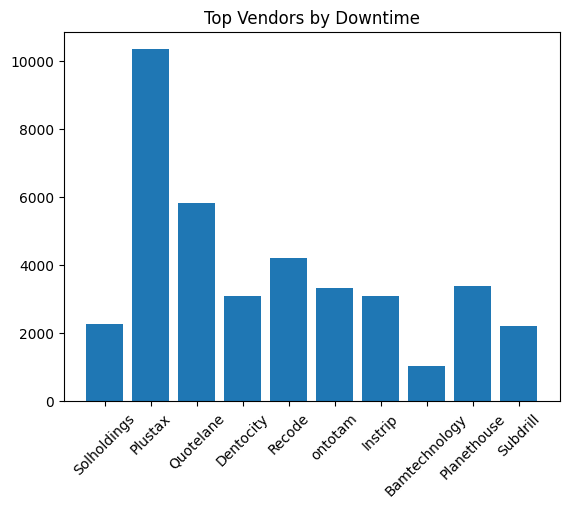

In [48]:
#Downtime theo Vendor
plt.figure()
plt.bar(top_vendor['Vendor'], top_vendor['Total Downtime'])
plt.xticks(rotation=45)
plt.title('Top Vendors by Downtime')
plt.show()

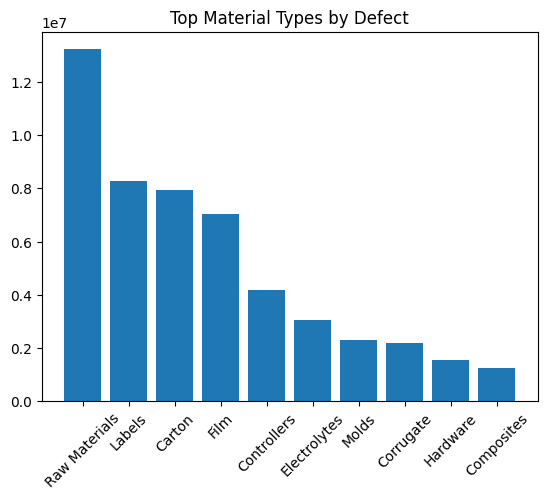

In [49]:
#Material gây lỗi nhiều nhất
material_defect = df.groupby('Material Type')['Defect Qty'].sum()\
                    .sort_values(ascending=False)\
                    .head(10)

plt.figure()
plt.bar(material_defect.index, material_defect.values)
plt.xticks(rotation=45)
plt.title('Top Material Types by Defect')
plt.show()

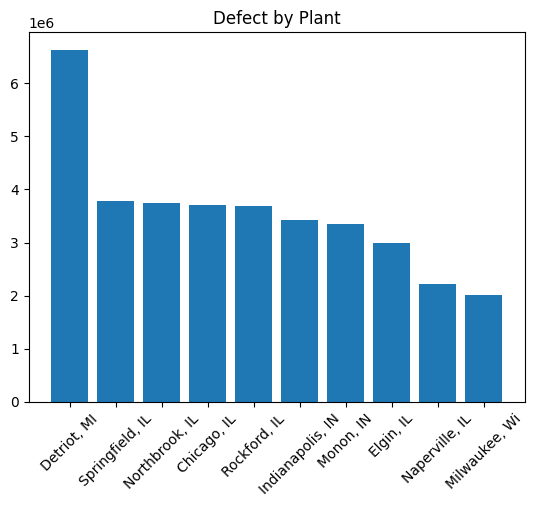

In [50]:
#Plant performance
plant_defect = df.groupby('Plant')['Defect Qty'].sum()\
                .sort_values(ascending=False)

plt.figure()
plt.bar(plant_defect.head(10).index, plant_defect.head(10).values)
plt.xticks(rotation=45)
plt.title('Defect by Plant')
plt.show()

<Axes: xlabel='Material Type', ylabel='Vendor'>

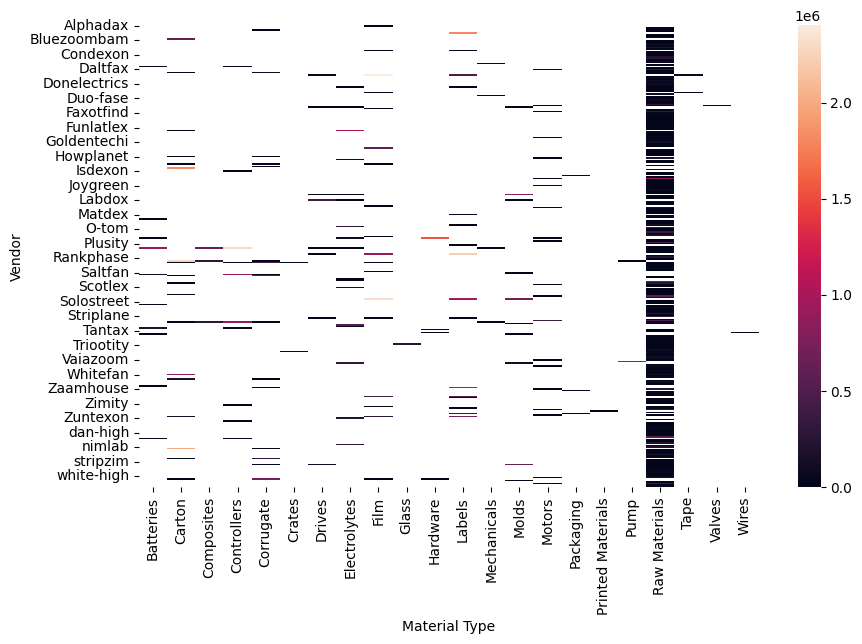

In [54]:
#Heatmap Vendor vs Material
pivot = df.pivot_table(
    values='Defect Qty',
    index='Vendor',
    columns='Material Type',
    aggfunc='sum'
)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot)

Solholding có số lượng lỗi lớn nhất, tuy nhiên Vendor Plustax có số lượng lỗi (cao thứ 2) và downtime cao nhất, cho thấy vấn đề về chất lượng vật liệu, đặc biệt trong nhóm Raw Material. Ngoài ra, lỗi tập trung tại plant Ditriot,MI.

-> Kết quả phân tích cho thấy sự chênh lệch rõ rệt về chất lượng giữa các nhà cung cấp:

Một số vendor có Total Defect và Downtime cao vượt trội, cho thấy chất lượng không ổn định

Có những vendor tuy số lỗi không quá cao nhưng Downtime lại lớn
Điều này cho thấy lỗi có tính nghiêm trọng cao, gây gián đoạn sản xuất

=> Không chỉ số lượng lỗi, mà mức độ ảnh hưởng của lỗi (downtime) cũng là yếu tố quan trọng khi đánh giá supplier.
Một số nhà máy (Plant) ghi nhận số lỗi cao hơn
Có thể do:
-Supplier cung cấp không đồng đều
- điều kiện vận hành tại plant

-> Phân tích cũng cho thấy chất lượng nhà cung cấp có ảnh hưởng đáng kể đến:

-Số lượng lỗi sản phẩm
-Thời gian dừng máy
-Hiệu suất vận hành tổng thể

==> Dựa trên kết quả phân tích, đề xuất các hành động sau:

1. Supplier Management
-Xem xét lại các vendor có defect và downtime cao
-Thiết lập tiêu chuẩn đánh giá chất lượng định kỳ
-Ưu tiên hợp tác với các vendor có hiệu suất tốt
2 .Quality Control
-Tăng cường kiểm tra đầu vào (incoming inspection)
-Tập trung vào các Material Type có tỷ lệ lỗi cao
3. Process Improvement
-Phân tích sâu các defect phổ biến để tìm root cause
-Kết hợp với các plant để cải thiện quy trình sản xuất
4. Monitoring & Dashboard
Xây dựng dashboard theo dõi real-time:
-Defect theo Vendor
-Downtime theo Plant
-TTDowntime theo thời gian

Một số nhà cung cấp đang thể hiện rủi ro cao và cần được ưu tiên đánh giá lại, trong khi một số khác hoạt động ổn định và có thể được xem là đối tác chiến lược.